In [1]:
import pandas as pd

In [2]:
import torch
from torch import nn, optim

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

In [4]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [5]:
import random

In [6]:
import numpy as np

In [7]:
import matplotlib.pyplot as plot

In [8]:
from sklearn.model_selection import train_test_split

In [13]:
from string import punctuation

In [81]:
df = pd.read_csv("D:/git/dados/nlp/imdb-reviews-pt-br.csv", encoding="utf-8")

In [82]:
df = df[["text_pt"]]
df

,text_pt
0,"Mais uma vez, o Sr. Costner arrumou um filme p..."
1,Este é um exemplo do motivo pelo qual a maiori...
2,"Primeiro de tudo eu odeio esses raps imbecis, ..."
3,Nem mesmo os Beatles puderam escrever músicas ...
4,Filmes de fotos de latão não é uma palavra apr...
...,...
49454,"Como a média de votos era muito baixa, e o fat..."
49455,O enredo teve algumas reviravoltas infelizes e...
49456,Estou espantado com a forma como este filme e ...
49457,A Christmas Together realmente veio antes do m...


In [83]:
MAX_PALAVRAS_FRASE = 30

In [84]:
TABLE_LIMPAR = str.maketrans("", "", "\u200b" + "\u000b" + punctuation)
def limpar( texto ):
    return texto.lower().translate(TABLE_LIMPAR)

In [85]:
frases_limpas = df["text_pt"].apply(limpar)

In [86]:
frases_selecionadas = frases_limpas[0:1000]

In [87]:
frases_selecionadas[10]

'cage interpreta um bêbado e é elogiado pela crítica elizabeth shue na verdade tem que fazer um amor com a parte mais desprezível e superestimada de estrume em hollywood eu literalmente vomitei enquanto assistia a esse filme claro que tive gripe mas isso não significa que este filme não tenha contribuído para o vômito no kamode por que nick cage não pode tocar em algo que ele pode realmente fazer como um ator ruim nick cage que é brilhante em um papel de mau ator parreira ninguém poderia fazer melhor a busca começa por nicks contrato com lúcifer ou lou cipher de night train to terror'

In [88]:
dicionario = { 
    "<UNKNOWN>": 0,
    "<PAD>": 1
}

In [89]:
contador_palavras = len(dicionario.keys())
lista_frases_numeros = [ ]
for frase in frases_selecionadas:
    lista_tokens_numericos = []
    for idx, token in enumerate(frase.split(" ")):
        if token in dicionario:
            numero = dicionario[token]
        else:
            numero = contador_palavras
            dicionario[token] = numero
            contador_palavras += 1
        lista_tokens_numericos.append( numero )
        if idx >= MAX_PALAVRAS_FRASE:
            break
    lista_frases_numeros.append( lista_tokens_numericos )

In [90]:
print(lista_frases_numeros[0])

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 2, 13, 14, 15, 5, 16, 17, 18, 19, 20, 21, 22, 23, 24, 18, 25, 26, 12, 27, 28]


In [91]:
print(len(dicionario))

5827


In [92]:
dicionario_reverso = {}
for chave in dicionario.keys():
    valor = dicionario[chave]
    dicionario_reverso[valor] = chave

In [93]:
print("Numero da palavra Filme: ", dicionario["filme"])
print("Palavra do numero 10: ", dicionario_reverso[10])

Numero da palavra Filme:  10
Palavra do numero 10:  filme


In [94]:
X_draft = []
Y_draft = []
for frase_numeros in lista_frases_numeros:
    for i in range(2, len(frase_numeros)):
        features = frase_numeros[0:i]
        label = frase_numeros[i]
        palavra = dicionario_reverso[label]
        X_draft.append(features)
        Y_draft.append(palavra)

In [105]:
print(X_draft[7])
print(Y_draft[7])

[2, 3, 4, 5, 6, 7, 8, 9, 10]
por


In [128]:
encoder = LabelEncoder()
oh_encoder = OneHotEncoder(sparse_output=False)

In [129]:
Y_label = encoder.fit_transform(Y_draft)
Y_label = Y_label.reshape(-1, 1)
Y_label

array([[5468],
       [3779],
       [4972],
       ...,
       [3289],
       [1894],
       [5371]], shape=(28998, 1))

In [130]:
encoder.classes_

array(['', '1', '10', ..., 'únicos', 'úteis', '”bloodline'],
      shape=(5673,), dtype='<U20')

In [131]:
Y_oh = oh_encoder.fit_transform(Y_label)
oh_encoder.categories_

[array([   0,    1,    2, ..., 5670, 5671, 5672], shape=(5673,))]

In [132]:
Y_oh

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(28998, 5673))

In [133]:
NUM_CLASSES = Y_oh.shape[1]
NUM_CLASSES

5673

In [134]:
# Y = torch.tensor(df["type_number"], dtype=torch.float32)
# Y = torch.reshape( Y, (-1, 1) )
# Y.shape
Y = torch.tensor(Y_oh, dtype=torch.float32)
Y

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [ ]:
# [0, 0, 1, 0, 0, 0, 1, 0, 1, 1] "Bom dia como vai voce" 
# [0, 1, 0, 0, 0, 1, 0, 1, 2, 0] "Ontem houve uma explosao de gas no bairro Jaguare em São Paulo"
# [0, 0, 0, 0, 0, 1, 0, 0, 1, 0] "Vou sair tchau"

In [ ]:
# dicionario = {
#     "Bom": 1,
#     "dia": 2,
#     "como": 3,
#     "vai": 4,
#     "voce": 5,
#     "Ontem": 6,
#     "houve": 7,
# ....
# }

# [0, 0, 0, 0,  0,  0,  0,  1,  2,  3,  4,  5] "Bom dia como vai voce" 
# [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] "Ontem houve uma explosao de gas no bairro Jaguare em São Paulo"
# [0, 0, 0, 0,  0,  0,  0,  0,  0, 18, 20, 21] "Vou sair tchau"

In [111]:
MAIOR_FRASE = 0
for lista_numeros in X_draft:
    if len(lista_numeros) > MAIOR_FRASE:
        MAIOR_FRASE = len(lista_numeros)
MAIOR_FRASE

30

In [107]:
def padding( lista_numeros, size, elemento_padding, left=True):
    numero_pads = size - len(lista_numeros)
    pads = []
    for _ in range(numero_pads):
        pads.append(elemento_padding)
    # pads = [1, 1, 1, 1, 1]
    nova_lista = []
    if left:
        nova_lista.extend(pads)
        nova_lista.extend(lista_numeros)
    else:
        nova_lista.extend(lista_numeros)
        nova_lista.extend(pads)
    return nova_lista

In [121]:
# valor_pad = dicionario["<PAD>"]
# padding(X_draft[7], 30, valor_pad, False)

In [112]:
valor_pad = dicionario["<PAD>"]
X_padded = []
for x in X_draft:
    X_padded.append(padding(x, MAIOR_FRASE, valor_pad))
    # pads = [1, 1, 1, 1, 1, 34, 56, 12, 0, 43, 2]

In [113]:
print(X_padded[0:5])

[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 6], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 6, 7]]


In [114]:
X = torch.tensor( X_padded, dtype=torch.int32 )
X.shape

torch.Size([28998, 30])

In [135]:
print(f"Y  dim({Y.ndim})\tshape={Y.shape}\ttype=({Y.dtype})")
print(f"X  dim({X.ndim})\tshape={X.shape}\ttype=({X.dtype})")

Y  dim(2)	shape=torch.Size([28998, 5673])	type=(torch.float32)
X  dim(2)	shape=torch.Size([28998, 30])	type=(torch.int32)


In [136]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 75)

In [118]:
print(f"{Y_train[0]}  -  {X_train[0]}")

tensor([0, 0, 0,  ..., 0, 0, 0], dtype=torch.int32)  -  tensor([   1,    1,    1,    1,   26, 4534,   95,  890, 3303,  171,   38,  140,
        3373,  751, 3760,   46,   30,    9,  623,   28, 5134,    5, 1325, 3088,
         541,  284, 5135,   44,   21,   78], dtype=torch.int32)


In [137]:
DIMENSOES = 50
MAX_PALAVRAS_APRENDIDAS = len(dicionario)
MAX_PALAVRAS_APRENDIDAS

5827

In [138]:
class ProcessadorTexto( nn.Module ):
    def __init__(self, embeddings_in, embedding_out, padding_idx, num_classes, hidden_size):
        super(ProcessadorTexto, self).__init__()

        self.embedding = nn.Embedding(num_embeddings = embeddings_in, 
                                      embedding_dim = embedding_out, 
                                      padding_idx = padding_idx)
        self.rnn = nn.RNN(
            input_size = embedding_out,
            hidden_size = hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        embedded = self.embedding( x )
        rnn_out, rnn_hidden = self.rnn( embedded )
        ultimo_estado = rnn_hidden[-1]
        logits = self.fc(ultimo_estado)
        return logits
        

In [142]:
modelo = ProcessadorTexto(embeddings_in = MAX_PALAVRAS_APRENDIDAS,
                          embedding_out = DIMENSOES,
                          padding_idx = valor_pad,
                          num_classes = NUM_CLASSES,
                          hidden_size = 50)
otimizador = optim.Adam( modelo.parameters(), lr=0.01)
criterio = nn.CrossEntropyLoss() # Cross Entropy Perda

In [143]:
lista_loss = []
for epoca in range(500):
    y_hat = modelo( X_train ) 
    loss = criterio( y_hat, Y_train )
    lista_loss.append( loss )
    if epoca % 10 == 0:
        print(f"Epoca: {epoca}\tLoss: {loss}")
    otimizador.zero_grad()
    loss.backward()
    otimizador.step()

Loss: 8.690947532653809
Loss: 6.46713399887085
Loss: 5.79789400100708
Loss: 5.107237815856934
Loss: 4.470976829528809
Loss: 3.919705390930176
Loss: 3.4772210121154785
Loss: 3.117496967315674
Loss: 2.810786724090576
Loss: 2.5428056716918945
Loss: 2.304344892501831
Loss: 2.1063339710235596
Loss: 1.9204907417297363
Loss: 1.7593902349472046
Loss: 1.6200859546661377
Loss: 1.4978991746902466
Loss: 1.3954137563705444
Loss: 1.2982441186904907
Loss: 1.2133595943450928
Loss: 1.1423816680908203
Loss: 1.2583332061767578
Loss: 1.1371887922286987
Loss: 1.0524725914001465
Loss: 0.9927926063537598
Loss: 0.945343554019928
Loss: 0.9062516689300537
Loss: 0.8705445528030396
Loss: 0.8433018922805786
Loss: 0.8155898451805115
Loss: 0.7910652756690979
Loss: 0.7641639113426208
Loss: 0.744337797164917
Loss: 0.7282074689865112
Loss: 0.709487795829773
Loss: 0.6895953416824341
Loss: 0.6778538227081299
Loss: 0.6642874479293823
Loss: 0.6527737975120544
Loss: 0.6472324132919312
Loss: 0.6305957436561584
Loss: 0.624033

C:\Users\anton\AppData\Local\Temp\ipykernel_16892\479406149.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  lista_tensor = torch.tensor( lista_loss )


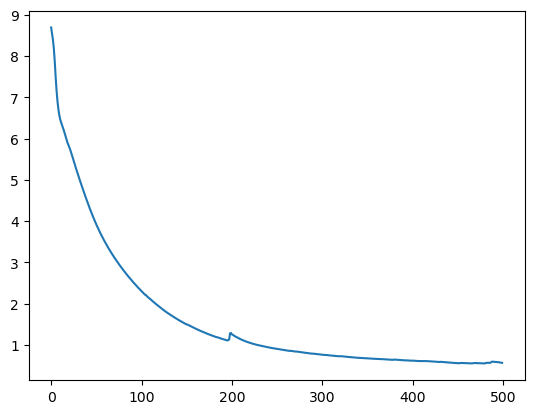

In [144]:
lista_tensor = torch.tensor( lista_loss ) 
plot.plot( lista_tensor )

In [171]:
posicao = random.randint(0, len(frases_selecionadas))
frase = frases_selecionadas[posicao]
print(f"Posicao: {posicao}")
print(f"Frase: {frase}")

Posicao: 260
Frase: uau essa versão do the racketeer foi difícil de assistir enquanto nenhum dos outros comentários mencionaram isso a versão de domínio público que eu assisti foi seriamente falho a faixa de som estava desligada em cerca de 10 segundos  o que significa que o diálogo e a ação nunca chegaram perto de corresponder então você ouviria algo acontecer bem antes de vêlo  uma proposta muito confusa o pior é onde você ouve um tiro e só mais tarde o sujeito é atingido e cai para a morte em um táxi enquanto isso seriamente prejudicou o filme ele também facilitou a concentração no diálogo  e mostrou as graves deficiências dele também o diálogo foi simplesmente horrível  muitas vezes entregue com quase nenhuma inflexão ou sentimento como um comentário disse foi como assistir a uma peça do ensino médio parte disso é compreensível já que o som era um novo meio mas o diálogo desse filme era ruim mesmo comparado a outros filmes de 1929  muito ruim e como em muitos desses primeiros filme

In [216]:
frase = "puxa a disciplina de processamento de linguagem natural é complicada"

In [218]:
# Tokeninzar e codificar a frase
unknown = dicionario["<UNKNOWN>"]
tokens = frase.split(" ")
lista_tokenizada = []
for token in tokens:
    lista_tokenizada.append(dicionario.get( token, unknown ))


valor_pad = dicionario["<PAD>"]
lista_padded = padding(lista_tokenizada[0:10], MAIOR_FRASE, valor_pad)
print(lista_padded)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 35, 0, 21, 0, 21, 0, 3865, 30, 0]


In [215]:
X_predict = torch.tensor(lista_padded)
Y_predict = modelo( X_predict )
pos_token = torch.argmax(Y_predict)
print("Frase parcial: ", " ".join(tokens[0:8]))
print("Tamanho Y_predict: ", len(Y_predict))
print("Token encontrado: ", pos_token)
palavra_encontrada = encoder.inverse_transform( [pos_token.item()] )
print("Palavra encontrada: ", palavra_encontrada)
print("Frase completa: ", " ".join(tokens[0:8]) + " " + palavra_encontrada)

Frase parcial:  está complicado assistir a este filme não é
Tamanho Y_predict:  5673
Token encontrado:  tensor(3779)
Palavra encontrada:  ['o']
Frase completa:  ['está complicado assistir a este filme não é o']


In [61]:
posicao = random.randint(0, 3500)
tipo_correto = df["Type"][posicao]
texto = df["Description"][posicao]
print(posicao, ":", tipo_correto, "<->", texto)
# texto =  "trade war occurs in all world, causing faminy and disgrace" # df["Description"][900]
# resultado = df["sentiment_number"][900]
# print(f"Resultado: {resultado}\t\tDescricao: {texto}")

3013 : General <-> Senior Airman Augustin Rios, a crew chief assigned to the 92nd Aircraft Maintenance Squadron, removes a KC-135 Stratotanker boom sighting window for cleaning during a no-notice Nuclear Operational Readiness Inspection at Fairchild Air Force Base, Washington, July 16, 2024. Air Mobility Command's Inspector General team conducted the no-notice NORI from July 16 - 18, during which the 92nd Air Refueling Wing and 141st ARW received same-day notification of the evaluation of the base's capability to perform as a nuclear support unit. Various capabilities at Fairchild AFB enable units to generate and...


In [62]:
vetorizador_teste = CountVectorizer( vocabulary = vocabulario, max_features = MAX_PALAVRAS )
X_teste = vetorizador_teste.fit_transform( [texto] )
X_teste = torch.tensor( [X_teste.toarray()], dtype=torch.float32 )
X_teste.shape

torch.Size([1, 1, 2000])

In [63]:
Y_hat_teste = modelo( X_teste )
resultado = Y_hat_teste.detach().numpy()
indice = np.argmax(resultado)
tipo = encoder.inverse_transform( [indice] )
print(f"Indice: {indice}\tTipo: {tipo}")

Indice: 2	Tipo: ['General']
